# Advanced layer types -- Image Classification

## 0. Import packages and modules

In [27]:
!pwd

/leonardo/home/userexternal/ywang003/multiGPU_AI_TTT_course_DL


In [28]:
!hostname

lrdn0019.leonardo.local


In [29]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

import pathlib

import sklearn
import tensorflow
import keras

print(sklearn.__version__)
print(tensorflow.__version__)
print(keras.__version__)

1.4.1.post1
2.15.0
2.15.0


In [30]:
# print GPU info

print(tensorflow.config.list_physical_devices('GPU'))

print("Num GPUs Available: ", len(tensorflow.config.list_physical_devices('GPU')))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Num GPUs Available:  1


## 1. Formulate / Outline the problem: Image classification

In [31]:
DATA_FOLDER = pathlib.Path('image_classification/') # change to location where you stored the data
train_images = np.load(DATA_FOLDER / 'train_images.npy')
val_images = np.load(DATA_FOLDER / 'test_images.npy')
train_labels = np.load(DATA_FOLDER / 'train_labels.npy')
val_labels = np.load(DATA_FOLDER / 'test_labels.npy')

## 2. Identify inputs and outputs

In [32]:
train_images.shape

(878, 64, 64, 3)

In [33]:
train_images.min(), train_images.max()

(0, 255)

In [34]:
train_labels.shape

(878,)

In [35]:
train_labels.min(), train_labels.max()

(0, 9)

## 3. Prepare data

In [36]:
train_images = train_images / 255.0
val_images = val_images / 255.0

## 4. Build a pretrained model

In [37]:
inputs = keras.Input(shape=train_images.shape[1:])
x = keras.layers.Conv2D(50, (3, 3), activation='relu')(inputs)
x = keras.layers.Conv2D(50, (3, 3), activation='relu')(x)
x = keras.layers.Flatten()(x)
outputs = keras.layers.Dense(10)(x)

model = keras.Model(inputs=inputs, outputs=outputs, name="dollar_street_model_small")

In [38]:
model.summary()

Model: "dollar_street_model_small"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 64, 64, 3)]       0         
                                                                 
 conv2d_2 (Conv2D)           (None, 62, 62, 50)        1400      
                                                                 
 conv2d_3 (Conv2D)           (None, 60, 60, 50)        22550     
                                                                 
 flatten_1 (Flatten)         (None, 180000)            0         
                                                                 
 dense_2 (Dense)             (None, 10)                1800010   
                                                                 
Total params: 1823960 (6.96 MB)
Trainable params: 1823960 (6.96 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [39]:
def create_nn():
    inputs = keras.Input(shape=train_images.shape[1:])
    x = keras.layers.Conv2D(50, (3, 3), activation='relu')(inputs)
    x = keras.layers.MaxPooling2D((2, 2))(x) # a new maxpooling layer
    x = keras.layers.Conv2D(50, (3, 3), activation='relu')(x)
    x = keras.layers.MaxPooling2D((2, 2))(x) # a new maxpooling layer (same as maxpool)
    x = keras.layers.Flatten()(x)
    x = keras.layers.Dense(50, activation='relu')(x) # a new Dense layer
    outputs = keras.layers.Dense(10)(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name="dollar_street_model")
    return model

model = create_nn()
model.summary()

Model: "dollar_street_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 64, 64, 3)]       0         
                                                                 
 conv2d_4 (Conv2D)           (None, 62, 62, 50)        1400      
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 31, 31, 50)        0         
 g2D)                                                            
                                                                 
 conv2d_5 (Conv2D)           (None, 29, 29, 50)        22550     
                                                                 
 max_pooling2d_3 (MaxPoolin  (None, 14, 14, 50)        0         
 g2D)                                                            
                                                                 
 flatten_2 (Flatten)         (None, 9800)      

## 5. Choose a loss function and optimizer

In [40]:
def compile_model(model):
    model.compile(optimizer='adam',
                  loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                  metrics=['accuracy'])

compile_model(model)

## 6. Train the model

In [41]:
history = model.fit(train_images, train_labels, epochs=10,
                    validation_data=(val_images, val_labels))

Epoch 1/10
28/28 [==============================] - 1s 8ms/step - loss: 2.3130 - accuracy: 0.1321 - val_loss: 2.2882 - val_accuracy: 0.1433
Epoch 2/10
28/28 [==============================] - 0s 3ms/step - loss: 2.2498 - accuracy: 0.1959 - val_loss: 2.2314 - val_accuracy: 0.1945
Epoch 3/10
28/28 [==============================] - 0s 3ms/step - loss: 2.1295 - accuracy: 0.2597 - val_loss: 2.1578 - val_accuracy: 0.2355
Epoch 4/10
28/28 [==============================] - 0s 3ms/step - loss: 1.9795 - accuracy: 0.3212 - val_loss: 2.1549 - val_accuracy: 0.2457
Epoch 5/10
28/28 [==============================] - 0s 3ms/step - loss: 1.7848 - accuracy: 0.4089 - val_loss: 2.1855 - val_accuracy: 0.2389
Epoch 6/10
28/28 [==============================] - 0s 3ms/step - loss: 1.6465 - accuracy: 0.4567 - val_loss: 2.1904 - val_accuracy: 0.2969
Epoch 7/10
28/28 [==============================] - 0s 3ms/step - loss: 1.4133 - accuracy: 0.5364 - val_loss: 2.2125 - val_accuracy: 0.2901
Epoch 8/10
28/28 [==

## 7. Perform a Prediction/Classification

## 8. Measure performance

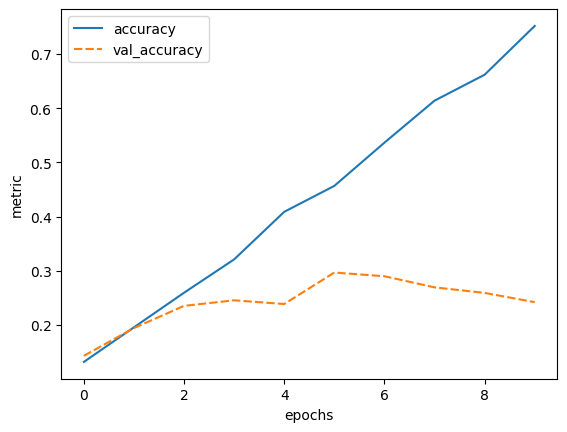

In [42]:
def plot_history(history, metrics):
    """
    Plot the training history

    Args:
        history (keras History object that is returned by model.fit())
        metrics(str, list): Metric or a list of metrics to plot
    """
    history_df = pd.DataFrame.from_dict(history.history)
    sns.lineplot(data=history_df[metrics])
    plt.xlabel("epochs")
    plt.ylabel("metric")

plot_history(history, ['accuracy', 'val_accuracy'])

In [43]:
def create_dense_model():
    inputs = keras.Input(shape=train_images.shape[1:])
    x = keras.layers.Flatten()(inputs)
    x = keras.layers.Dense(50, activation='relu')(x)
    x = keras.layers.Dense(50, activation='relu')(x)
    outputs = keras.layers.Dense(10)(x)
    return keras.models.Model(inputs=inputs, outputs=outputs,
                              name='dense_model')

dense_model = create_dense_model()
dense_model.summary()

Model: "dense_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_4 (InputLayer)        [(None, 64, 64, 3)]       0         
                                                                 
 flatten_3 (Flatten)         (None, 12288)             0         
                                                                 
 dense_5 (Dense)             (None, 50)                614450    
                                                                 
 dense_6 (Dense)             (None, 50)                2550      
                                                                 
 dense_7 (Dense)             (None, 10)                510       
                                                                 
Total params: 617510 (2.36 MB)
Trainable params: 617510 (2.36 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


Epoch 1/20
28/28 [==============================] - 1s 7ms/step - loss: 2.6671 - accuracy: 0.1150 - val_loss: 2.3301 - val_accuracy: 0.1672
Epoch 2/20
28/28 [==============================] - 0s 3ms/step - loss: 2.3125 - accuracy: 0.1640 - val_loss: 2.3169 - val_accuracy: 0.1399
Epoch 3/20
28/28 [==============================] - 0s 3ms/step - loss: 2.2366 - accuracy: 0.1879 - val_loss: 2.2572 - val_accuracy: 0.1672
Epoch 4/20
28/28 [==============================] - 0s 3ms/step - loss: 2.1942 - accuracy: 0.2278 - val_loss: 2.2198 - val_accuracy: 0.1980
Epoch 5/20
28/28 [==============================] - 0s 3ms/step - loss: 2.1219 - accuracy: 0.2517 - val_loss: 2.3391 - val_accuracy: 0.1843
Epoch 6/20
28/28 [==============================] - 0s 3ms/step - loss: 2.1039 - accuracy: 0.2369 - val_loss: 2.4406 - val_accuracy: 0.1604
Epoch 7/20
28/28 [==============================] - 0s 3ms/step - loss: 2.0241 - accuracy: 0.3030 - val_loss: 2.2577 - val_accuracy: 0.2218
Epoch 8/20
28/28 [==

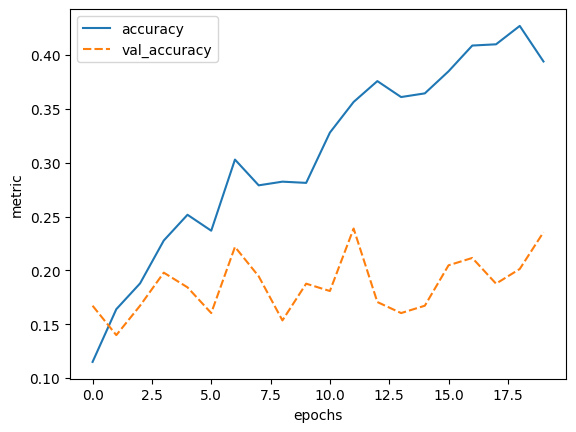

In [44]:
compile_model(dense_model)
history = dense_model.fit(train_images, train_labels, epochs=20,
                    validation_data=(val_images, val_labels))
plot_history(history, ['accuracy', 'val_accuracy'])

## 9. Refine the model

In [45]:
def create_nn_with_dropout():
    inputs = keras.Input(shape=train_images.shape[1:])
    x = keras.layers.Conv2D(50, (3, 3), activation='relu')(inputs)
    x = keras.layers.MaxPooling2D((2, 2))(x)
    x = keras.layers.Dropout(0.8)(x) # This is new!

    x = keras.layers.Conv2D(50, (3, 3), activation='relu')(x)
    x = keras.layers.MaxPooling2D((2, 2))(x)
    x = keras.layers.Dropout(0.8)(x) # This is new!

    x = keras.layers.Conv2D(50, (3, 3), activation='relu')(x)
    x = keras.layers.MaxPooling2D((2, 2))(x)
    x = keras.layers.Dropout(0.8)(x) # This is new!

    x = keras.layers.Flatten()(x)
    x = keras.layers.Dense(50, activation='relu')(x)
    outputs = keras.layers.Dense(10)(x)
    model = keras.Model(inputs=inputs, outputs=outputs, name="dropout_model")
    return model

model_dropout = create_nn_with_dropout()
model_dropout.summary()

Model: "dropout_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_5 (InputLayer)        [(None, 64, 64, 3)]       0         
                                                                 
 conv2d_6 (Conv2D)           (None, 62, 62, 50)        1400      
                                                                 
 max_pooling2d_4 (MaxPoolin  (None, 31, 31, 50)        0         
 g2D)                                                            
                                                                 
 dropout_1 (Dropout)         (None, 31, 31, 50)        0         
                                                                 
 conv2d_7 (Conv2D)           (None, 29, 29, 50)        22550     
                                                                 
 max_pooling2d_5 (MaxPoolin  (None, 14, 14, 50)        0         
 g2D)                                                

In [46]:
compile_model(model_dropout)

history = model_dropout.fit(train_images, train_labels, epochs=20,
                    validation_data=(val_images, val_labels))

Epoch 1/20
28/28 [==============================] - 1s 10ms/step - loss: 2.5114 - accuracy: 0.0991 - val_loss: 2.3023 - val_accuracy: 0.1024
Epoch 2/20
28/28 [==============================] - 0s 4ms/step - loss: 2.3001 - accuracy: 0.0888 - val_loss: 2.3014 - val_accuracy: 0.1570
Epoch 3/20
28/28 [==============================] - 0s 4ms/step - loss: 2.2996 - accuracy: 0.1082 - val_loss: 2.3006 - val_accuracy: 0.1365
Epoch 4/20
28/28 [==============================] - 0s 4ms/step - loss: 2.2982 - accuracy: 0.1276 - val_loss: 2.3003 - val_accuracy: 0.1263
Epoch 5/20
28/28 [==============================] - 0s 4ms/step - loss: 2.2856 - accuracy: 0.1390 - val_loss: 2.2988 - val_accuracy: 0.1263
Epoch 6/20
28/28 [==============================] - 0s 4ms/step - loss: 2.2840 - accuracy: 0.1492 - val_loss: 2.2980 - val_accuracy: 0.1263
Epoch 7/20
28/28 [==============================] - 0s 4ms/step - loss: 2.2749 - accuracy: 0.1572 - val_loss: 2.2972 - val_accuracy: 0.1263
Epoch 8/20
28/28 [=

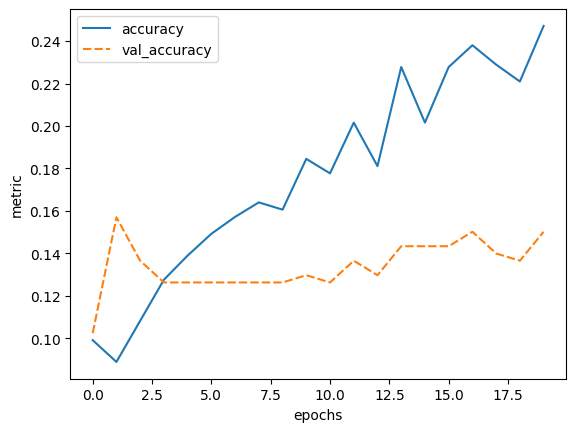

In [47]:
plot_history(history, ['accuracy', 'val_accuracy'])

In [48]:
def create_nn_with_hp(dropout_rate, n_layers):
    inputs = keras.Input(shape=train_images.shape[1:])
    x = inputs
    for layer in range(n_layers):
        x = keras.layers.Conv2D(50, (3, 3), activation='relu')(x)
        x = keras.layers.MaxPooling2D((2, 2))(x)
    x = keras.layers.Dropout(dropout_rate)(x)
    x = keras.layers.Flatten()(x)
    x = keras.layers.Dense(50, activation='relu')(x)
    outputs = keras.layers.Dense(10)(x)
    model = keras.Model(inputs=inputs, outputs=outputs, name="cifar_model")
    return model

In [49]:
# here we need to install keras_tuner
# using terminal at the login node and come to the `multiGPU_AI_TTT_course_DL` directory
# run the command at the terminal `git clone https://github.com/keras-team/keras-tuner.git`
# then run `cd keras-tuner/` and `pip install .
# if everything goes well, run this cell

import sys
sys.path.append(r"/leonardo/home/userexternal/ywang003/multiGPU_AI_TTT_course_DL/keras-tuner")
import keras_tuner

In [50]:
hp = keras_tuner.HyperParameters()

def build_model(hp):
    # Define values for hyperparameters to try out:
    n_layers = hp.Int("n_layers", min_value=1, max_value=2, step=1)
    dropout_rate = hp.Float("dropout_rate", min_value=0.2, max_value=0.8, step=0.3)

    model = create_nn_with_hp(dropout_rate, n_layers)
    compile_model(model)
    return model

tuner = keras_tuner.GridSearch(build_model, objective='val_loss')

tuner.search(train_images, train_labels, epochs=20,
             validation_data=(val_images, val_labels))

Reloading Tuner from ./untitled_project/tuner0.json


In [51]:
tuner.results_summary()

Results summary
Results in ./untitled_project
Showing 10 best trials
Objective(name="val_loss", direction="min")

Trial 0002 summary
Hyperparameters:
n_layers: 1
dropout_rate: 0.8
Score: 2.0518956184387207

Trial 0003 summary
Hyperparameters:
n_layers: 2
dropout_rate: 0.2
Score: 2.085221767425537

Trial 0000 summary
Hyperparameters:
n_layers: 1
dropout_rate: 0.2
Score: 2.1265811920166016

Trial 0005 summary
Hyperparameters:
n_layers: 2
dropout_rate: 0.8
Score: 2.12943172454834

Trial 0001 summary
Hyperparameters:
n_layers: 1
dropout_rate: 0.5
Score: 2.1351468563079834

Trial 0004 summary
Hyperparameters:
n_layers: 2
dropout_rate: 0.5
Score: 2.1431968212127686


## 10. Share model

In [52]:
model.save('image_classification.keras')